# Z-Score Clustering for NAIP

In [2]:
import pandas as pd
import os
from numpy.random import seed

In [3]:
df = pd.read_csv(r"Z_SCORE_2_NAIP_Dataset_MLA_New_Zeros_v2.csv") #adding all variables, dropping NaN

In [4]:
df.head()

,Location,Author,Year,Sample,Fe2O3 (%),MgO (%),TiO2 (%),Cr (ppm),Ni (ppm),Cu (ppm),...,Cr (Z),Ni(Z),Cu(Z),Ir (Z),Ru (Z),Rh (Z),Pt (Z),Pd (Z),Pt/Pd,Pt/Pd (Z)
0,Iceland,Momme,2003,BALK,14.90,5.05,4.59,28.0,35.0,39.0,...,-0.956206,-0.775195,-1.183247,-0.746816,-0.683316,-1.056380,-1.324968,-1.187426,0.659574,-0.565070
1,Iceland,Momme,2003,BTHO,10.10,10.10,0.96,506.0,186.0,120.0,...,0.053455,-0.201514,-0.061289,-0.474778,0.554977,0.337289,-0.385261,-0.082642,0.670927,-0.551383
2,Iceland,Momme,2003,D27,10.40,13.00,0.47,1173.0,562.0,81.0,...,1.462333,1.226990,-0.601491,-0.251388,0.142213,0.214318,-0.160601,0.745468,0.483962,-0.776812
3,Iceland,Momme,2003,D7,9.47,11.90,0.49,1342.0,352.0,88.0,...,1.819305,0.429155,-0.504532,-0.127283,0.570853,1.034124,0.192091,1.108005,0.527200,-0.724679
4,Iceland,Momme,2003,GR98-01,13.20,6.04,2.51,117.0,55.0,90.0,...,-0.768215,-0.699210,-0.476829,-0.815653,-0.786508,-1.056380,-1.293563,-1.240853,2.315789,1.431887


## k=3 All variables

In [5]:
#feature selection - doesn't need to be done like this, entire dataset can be considered
df.sub = df[['Location','Fe (Z)','Mg (Z)','Ti (Z)','Cr (Z)','Ni(Z)','Cu(Z)', 'Ir (Z)','Ru (Z)','Rh (Z)','Pt (Z)','Pd (Z)',]] 

In [6]:
# df.sub.head()
len(df.sub) - len(df.sub.dropna())

0

In [7]:
## Create DF with no missing values (any row with an NaN is deleted)
dfSubFinal = df.sub.copy()
dfSubFinal = dfSubFinal.dropna()
dfSubFinal.head()
print(len(dfSubFinal), len(df.sub))

259 259


In [8]:
# Convert to array
dfSubFinalarray = dfSubFinal.values
dfSubFinalarray

array([['Iceland', 1.464795422, -1.025389071, ..., -1.056379659,
        -1.324967541, -1.187426335],
       ['Iceland', -1.347141919, 0.08992710599999999, ...,
        0.33728915600000003, -0.385260702, -0.0826425],
       ['Iceland', -1.171395835, 0.730405702, ..., 0.21431837899999998,
        -0.160600713, 0.745468355],
       ...,
       ['W Greenland', -1.171395835, -1.131399322, ..., 0.386477468,
        0.581018823, 0.146328243],
       ['W Greenland', -0.878485695, -0.051419895, ..., -0.605486807,
        -0.585763704, -0.771462819],
       ['W Greenland', 2.343525841, -0.837662586, ..., 0.288100845,
        0.064059277, 1.08510829]], dtype=object)

In [9]:
dfSubFinal.head()

,Location,Fe (Z),Mg (Z),Ti (Z),Cr (Z),Ni(Z),Cu(Z),Ir (Z),Ru (Z),Rh (Z),Pt (Z),Pd (Z)
0,Iceland,1.464795,-1.025389,3.596851,-0.956206,-0.775195,-1.183247,-0.746816,-0.683316,-1.056380,-1.324968,-1.187426
1,Iceland,-1.347142,0.089927,-0.728239,0.053455,-0.201514,-0.061289,-0.474778,0.554977,0.337289,-0.385261,-0.082642
2,Iceland,-1.171396,0.730406,-1.312067,1.462333,1.226990,-0.601491,-0.251388,0.142213,0.214318,-0.160601,0.745468
3,Iceland,-1.716209,0.487466,-1.288237,1.819305,0.429155,-0.504532,-0.127283,0.570853,1.034124,0.192091,1.108005
4,Iceland,0.468901,-0.806743,1.118562,-0.768215,-0.699210,-0.476829,-0.815653,-0.786508,-1.056380,-1.293563,-1.240853


In [10]:
## K-means
# Fit k-means model
from sklearn.cluster import KMeans
k = 3
mdl1 = KMeans(n_clusters=k, n_jobs=-1, init = 'random', n_init= 1200, max_iter=1500) # -1 uses all cores
mdl1.fit(X=dfSubFinalarray[:,1:11]) # using only the selected variables e.g. major, trace and PGE

KMeans(algorithm='auto', copy_x=True, init='random', max_iter=1500,
       n_clusters=3, n_init=1200, n_jobs=-1, precompute_distances='auto',
       random_state=None, tol=0.0001, verbose=0)

No handles with labels found to put in legend.


Index(['Location', 'Fe (Z)', 'Mg (Z)', 'Ti (Z)', 'Cr (Z)', 'Ni(Z)', 'Cu(Z)',
       'Ir (Z)', 'Ru (Z)', 'Rh (Z)', 'Pt (Z)', 'Pd (Z)', 'k=3_All'],
      dtype='object')


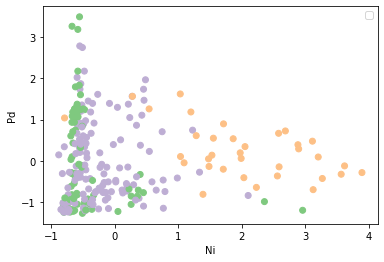

In [13]:
## Plotting clusters
from palettable.colorbrewer.qualitative import Accent_6
colDict = {0: Accent_6.hex_colors[0], 1: Accent_6.hex_colors[1], 2: Accent_6.hex_colors[2], 3: Accent_6.hex_colors[3]}
myCol = [colDict[i] for i in mdl1.labels_]

print(dfSubFinal.columns)

# Plot results
import matplotlib.pyplot as plt
plt.scatter(dfSubFinalarray[:, 5], dfSubFinalarray[:, 11], c=myCol)
plt.xlabel('Ni')
plt.ylabel('Pd')
plt.legend()

In [14]:
# append new cluster groups
dfSubFinal['k=3_All'] = mdl1.labels_
dfSubFinal.head()

,Location,Fe (Z),Mg (Z),Ti (Z),Cr (Z),Ni(Z),Cu(Z),Ir (Z),Ru (Z),Rh (Z),Pt (Z),Pd (Z),k=3_All
0,Iceland,1.464795,-1.025389,3.596851,-0.956206,-0.775195,-1.183247,-0.746816,-0.683316,-1.056380,-1.324968,-1.187426,0
1,Iceland,-1.347142,0.089927,-0.728239,0.053455,-0.201514,-0.061289,-0.474778,0.554977,0.337289,-0.385261,-0.082642,1
2,Iceland,-1.171396,0.730406,-1.312067,1.462333,1.226990,-0.601491,-0.251388,0.142213,0.214318,-0.160601,0.745468,1
3,Iceland,-1.716209,0.487466,-1.288237,1.819305,0.429155,-0.504532,-0.127283,0.570853,1.034124,0.192091,1.108005,1
4,Iceland,0.468901,-0.806743,1.118562,-0.768215,-0.699210,-0.476829,-0.815653,-0.786508,-1.056380,-1.293563,-1.240853,0


## k=3, PGE+Trace 

In [15]:
## K-means
# Fit k-means model
from sklearn.cluster import KMeans
k = 3
mdl2 = KMeans(n_clusters=k, n_jobs=-1, init = 'random', n_init= 1200, max_iter=1500) # -1 uses all cores
mdl2.fit(X=dfSubFinalarray[:,4:11]) # using only the selected variables e.g. major, trace and PGE

KMeans(algorithm='auto', copy_x=True, init='random', max_iter=1500,
       n_clusters=3, n_init=1200, n_jobs=-1, precompute_distances='auto',
       random_state=None, tol=0.0001, verbose=0)

No handles with labels found to put in legend.


Index(['Location', 'Fe (Z)', 'Mg (Z)', 'Ti (Z)', 'Cr (Z)', 'Ni(Z)', 'Cu(Z)',
       'Ir (Z)', 'Ru (Z)', 'Rh (Z)', 'Pt (Z)', 'Pd (Z)', 'k=3_All'],
      dtype='object')


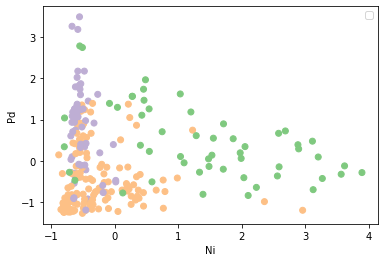

In [16]:
## Plotting clusters
from palettable.colorbrewer.qualitative import Accent_6
colDict = {0: Accent_6.hex_colors[0], 1: Accent_6.hex_colors[1], 2: Accent_6.hex_colors[2], 3: Accent_6.hex_colors[3]}
myCol = [colDict[i] for i in mdl2.labels_]

print(dfSubFinal.columns)

# Plot results
import matplotlib.pyplot as plt
plt.scatter(dfSubFinalarray[:, 5], dfSubFinalarray[:, 11], c=myCol)
plt.xlabel('Ni')
plt.ylabel('Pd')
plt.legend()

In [17]:
# append new cluster groups
dfSubFinal['k=3_PGE+Trace'] = mdl2.labels_
dfSubFinal.head()

,Location,Fe (Z),Mg (Z),Ti (Z),Cr (Z),Ni(Z),Cu(Z),Ir (Z),Ru (Z),Rh (Z),Pt (Z),Pd (Z),k=3_All,k=3_PGE+Trace
0,Iceland,1.464795,-1.025389,3.596851,-0.956206,-0.775195,-1.183247,-0.746816,-0.683316,-1.056380,-1.324968,-1.187426,0,2
1,Iceland,-1.347142,0.089927,-0.728239,0.053455,-0.201514,-0.061289,-0.474778,0.554977,0.337289,-0.385261,-0.082642,1,2
2,Iceland,-1.171396,0.730406,-1.312067,1.462333,1.226990,-0.601491,-0.251388,0.142213,0.214318,-0.160601,0.745468,1,2
3,Iceland,-1.716209,0.487466,-1.288237,1.819305,0.429155,-0.504532,-0.127283,0.570853,1.034124,0.192091,1.108005,1,0
4,Iceland,0.468901,-0.806743,1.118562,-0.768215,-0.699210,-0.476829,-0.815653,-0.786508,-1.056380,-1.293563,-1.240853,0,2


# k=3, PGE Only

In [18]:
## K-means
# Fit k-means model
from sklearn.cluster import KMeans
k = 3
mdl3 = KMeans(n_clusters=k, n_jobs=-1, init = 'random', n_init= 1200, max_iter=1500) # -1 uses all cores
mdl3.fit(X=dfSubFinalarray[:,7:11]) # using only the selected variables e.g. major, trace and PGE

KMeans(algorithm='auto', copy_x=True, init='random', max_iter=1500,
       n_clusters=3, n_init=1200, n_jobs=-1, precompute_distances='auto',
       random_state=None, tol=0.0001, verbose=0)

No handles with labels found to put in legend.


Index(['Location', 'Fe (Z)', 'Mg (Z)', 'Ti (Z)', 'Cr (Z)', 'Ni(Z)', 'Cu(Z)',
       'Ir (Z)', 'Ru (Z)', 'Rh (Z)', 'Pt (Z)', 'Pd (Z)', 'k=3_All',
       'k=3_PGE+Trace'],
      dtype='object')


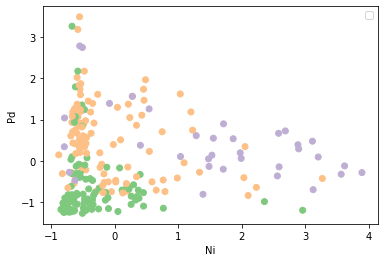

In [19]:
## Plotting clusters
from palettable.colorbrewer.qualitative import Accent_6
colDict = {0: Accent_6.hex_colors[0], 1: Accent_6.hex_colors[1], 2: Accent_6.hex_colors[2], 3: Accent_6.hex_colors[3]}
myCol = [colDict[i] for i in mdl3.labels_]

print(dfSubFinal.columns)

# Plot results
import matplotlib.pyplot as plt
plt.scatter(dfSubFinalarray[:, 5], dfSubFinalarray[:, 11], c=myCol)
plt.xlabel('Ni')
plt.ylabel('Pd')
plt.legend()

In [20]:
# append new cluster groups
dfSubFinal['k=3_PGE'] = mdl3.labels_
dfSubFinal.head()

,Location,Fe (Z),Mg (Z),Ti (Z),Cr (Z),Ni(Z),Cu(Z),Ir (Z),Ru (Z),Rh (Z),Pt (Z),Pd (Z),k=3_All,k=3_PGE+Trace,k=3_PGE
0,Iceland,1.464795,-1.025389,3.596851,-0.956206,-0.775195,-1.183247,-0.746816,-0.683316,-1.056380,-1.324968,-1.187426,0,2,0
1,Iceland,-1.347142,0.089927,-0.728239,0.053455,-0.201514,-0.061289,-0.474778,0.554977,0.337289,-0.385261,-0.082642,1,2,2
2,Iceland,-1.171396,0.730406,-1.312067,1.462333,1.226990,-0.601491,-0.251388,0.142213,0.214318,-0.160601,0.745468,1,2,2
3,Iceland,-1.716209,0.487466,-1.288237,1.819305,0.429155,-0.504532,-0.127283,0.570853,1.034124,0.192091,1.108005,1,0,2
4,Iceland,0.468901,-0.806743,1.118562,-0.768215,-0.699210,-0.476829,-0.815653,-0.786508,-1.056380,-1.293563,-1.240853,0,2,0


# k=2, All variables

In [21]:
## K-means
# Fit k-means model
from sklearn.cluster import KMeans
k = 2
mdl4 = KMeans(n_clusters=k, n_jobs=-1, init = 'random', n_init= 1200, max_iter=1500) # -1 uses all cores
mdl4.fit(X=dfSubFinalarray[:,1:11]) # using only the selected variables e.g. major, trace and PGE

KMeans(algorithm='auto', copy_x=True, init='random', max_iter=1500,
       n_clusters=2, n_init=1200, n_jobs=-1, precompute_distances='auto',
       random_state=None, tol=0.0001, verbose=0)

No handles with labels found to put in legend.


Index(['Location', 'Fe (Z)', 'Mg (Z)', 'Ti (Z)', 'Cr (Z)', 'Ni(Z)', 'Cu(Z)',
       'Ir (Z)', 'Ru (Z)', 'Rh (Z)', 'Pt (Z)', 'Pd (Z)', 'k=3_All',
       'k=3_PGE+Trace', 'k=3_PGE'],
      dtype='object')


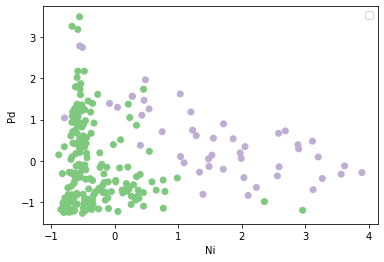

In [22]:
## Plotting clusters
from palettable.colorbrewer.qualitative import Accent_6
colDict = {0: Accent_6.hex_colors[0], 1: Accent_6.hex_colors[1], 2: Accent_6.hex_colors[2], 3: Accent_6.hex_colors[3]}
myCol = [colDict[i] for i in mdl4.labels_]

print(dfSubFinal.columns)

# Plot results
import matplotlib.pyplot as plt
plt.scatter(dfSubFinalarray[:, 5], dfSubFinalarray[:, 11], c=myCol)
plt.xlabel('Ni')
plt.ylabel('Pd')
plt.legend()

In [23]:
# append new cluster groups
dfSubFinal['k=2_All'] = mdl4.labels_
dfSubFinal.head()

,Location,Fe (Z),Mg (Z),Ti (Z),Cr (Z),Ni(Z),Cu(Z),Ir (Z),Ru (Z),Rh (Z),Pt (Z),Pd (Z),k=3_All,k=3_PGE+Trace,k=3_PGE,k=2_All
0,Iceland,1.464795,-1.025389,3.596851,-0.956206,-0.775195,-1.183247,-0.746816,-0.683316,-1.056380,-1.324968,-1.187426,0,2,0,0
1,Iceland,-1.347142,0.089927,-0.728239,0.053455,-0.201514,-0.061289,-0.474778,0.554977,0.337289,-0.385261,-0.082642,1,2,2,0
2,Iceland,-1.171396,0.730406,-1.312067,1.462333,1.226990,-0.601491,-0.251388,0.142213,0.214318,-0.160601,0.745468,1,2,2,1
3,Iceland,-1.716209,0.487466,-1.288237,1.819305,0.429155,-0.504532,-0.127283,0.570853,1.034124,0.192091,1.108005,1,0,2,1
4,Iceland,0.468901,-0.806743,1.118562,-0.768215,-0.699210,-0.476829,-0.815653,-0.786508,-1.056380,-1.293563,-1.240853,0,2,0,0


# k=2, PGE+Trace

In [24]:
## K-means
# Fit k-means model
from sklearn.cluster import KMeans
k = 2
mdl5 = KMeans(n_clusters=k, n_jobs=-1, init = 'random', n_init= 1200, max_iter=1500) # -1 uses all cores
mdl5.fit(X=dfSubFinalarray[:,4:11]) # using only the selected variables e.g. major, trace and PGE

KMeans(algorithm='auto', copy_x=True, init='random', max_iter=1500,
       n_clusters=2, n_init=1200, n_jobs=-1, precompute_distances='auto',
       random_state=None, tol=0.0001, verbose=0)

No handles with labels found to put in legend.


Index(['Location', 'Fe (Z)', 'Mg (Z)', 'Ti (Z)', 'Cr (Z)', 'Ni(Z)', 'Cu(Z)',
       'Ir (Z)', 'Ru (Z)', 'Rh (Z)', 'Pt (Z)', 'Pd (Z)', 'k=3_All',
       'k=3_PGE+Trace', 'k=3_PGE', 'k=2_All'],
      dtype='object')


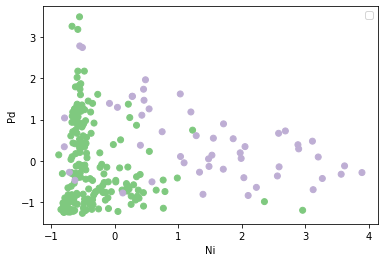

In [25]:
## Plotting clusters
from palettable.colorbrewer.qualitative import Accent_6
colDict = {0: Accent_6.hex_colors[0], 1: Accent_6.hex_colors[1], 2: Accent_6.hex_colors[2], 3: Accent_6.hex_colors[3]}
myCol = [colDict[i] for i in mdl5.labels_]

print(dfSubFinal.columns)

# Plot results
import matplotlib.pyplot as plt
plt.scatter(dfSubFinalarray[:, 5], dfSubFinalarray[:, 11], c=myCol)
plt.xlabel('Ni')
plt.ylabel('Pd')
plt.legend()

In [26]:
# append new cluster groups
dfSubFinal['k=2_PGE+Trace'] = mdl5.labels_
dfSubFinal.head()

,Location,Fe (Z),Mg (Z),Ti (Z),Cr (Z),Ni(Z),Cu(Z),Ir (Z),Ru (Z),Rh (Z),Pt (Z),Pd (Z),k=3_All,k=3_PGE+Trace,k=3_PGE,k=2_All,k=2_PGE+Trace
0,Iceland,1.464795,-1.025389,3.596851,-0.956206,-0.775195,-1.183247,-0.746816,-0.683316,-1.056380,-1.324968,-1.187426,0,2,0,0,0
1,Iceland,-1.347142,0.089927,-0.728239,0.053455,-0.201514,-0.061289,-0.474778,0.554977,0.337289,-0.385261,-0.082642,1,2,2,0,0
2,Iceland,-1.171396,0.730406,-1.312067,1.462333,1.226990,-0.601491,-0.251388,0.142213,0.214318,-0.160601,0.745468,1,2,2,1,0
3,Iceland,-1.716209,0.487466,-1.288237,1.819305,0.429155,-0.504532,-0.127283,0.570853,1.034124,0.192091,1.108005,1,0,2,1,1
4,Iceland,0.468901,-0.806743,1.118562,-0.768215,-0.699210,-0.476829,-0.815653,-0.786508,-1.056380,-1.293563,-1.240853,0,2,0,0,0


# k=2, PGE Only

In [27]:
## K-means
# Fit k-means model
from sklearn.cluster import KMeans
k = 2
mdl6 = KMeans(n_clusters=k, n_jobs=-1, init = 'random', n_init= 1200, max_iter=1500) # -1 uses all cores
mdl6.fit(X=dfSubFinalarray[:,7:11]) # using only the selected variables e.g. major, trace and PGE

KMeans(algorithm='auto', copy_x=True, init='random', max_iter=1500,
       n_clusters=2, n_init=1200, n_jobs=-1, precompute_distances='auto',
       random_state=None, tol=0.0001, verbose=0)

No handles with labels found to put in legend.


Index(['Location', 'Fe (Z)', 'Mg (Z)', 'Ti (Z)', 'Cr (Z)', 'Ni(Z)', 'Cu(Z)',
       'Ir (Z)', 'Ru (Z)', 'Rh (Z)', 'Pt (Z)', 'Pd (Z)', 'k=3_All',
       'k=3_PGE+Trace', 'k=3_PGE', 'k=2_All', 'k=2_PGE+Trace'],
      dtype='object')


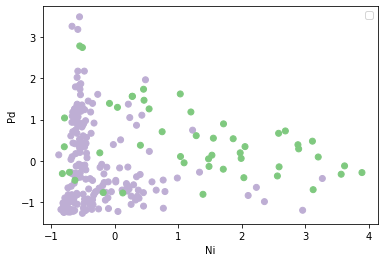

In [28]:
## Plotting clusters
from palettable.colorbrewer.qualitative import Accent_6
colDict = {0: Accent_6.hex_colors[0], 1: Accent_6.hex_colors[1], 2: Accent_6.hex_colors[2], 3: Accent_6.hex_colors[3]}
myCol = [colDict[i] for i in mdl6.labels_]

print(dfSubFinal.columns)

# Plot results
import matplotlib.pyplot as plt
plt.scatter(dfSubFinalarray[:, 5], dfSubFinalarray[:, 11], c=myCol)
plt.xlabel('Ni')
plt.ylabel('Pd')
plt.legend()

In [29]:
# append new cluster groups
dfSubFinal['k=2_PGE'] = mdl6.labels_
dfSubFinal.head()

,Location,Fe (Z),Mg (Z),Ti (Z),Cr (Z),Ni(Z),Cu(Z),Ir (Z),Ru (Z),Rh (Z),Pt (Z),Pd (Z),k=3_All,k=3_PGE+Trace,k=3_PGE,k=2_All,k=2_PGE+Trace,k=2_PGE
0,Iceland,1.464795,-1.025389,3.596851,-0.956206,-0.775195,-1.183247,-0.746816,-0.683316,-1.056380,-1.324968,-1.187426,0,2,0,0,0,1
1,Iceland,-1.347142,0.089927,-0.728239,0.053455,-0.201514,-0.061289,-0.474778,0.554977,0.337289,-0.385261,-0.082642,1,2,2,0,0,1
2,Iceland,-1.171396,0.730406,-1.312067,1.462333,1.226990,-0.601491,-0.251388,0.142213,0.214318,-0.160601,0.745468,1,2,2,1,0,1
3,Iceland,-1.716209,0.487466,-1.288237,1.819305,0.429155,-0.504532,-0.127283,0.570853,1.034124,0.192091,1.108005,1,0,2,1,1,1
4,Iceland,0.468901,-0.806743,1.118562,-0.768215,-0.699210,-0.476829,-0.815653,-0.786508,-1.056380,-1.293563,-1.240853,0,2,0,0,0,1


# k=4_All

In [30]:
## K-means
# Fit k-means model
from sklearn.cluster import KMeans
k = 4
mdl7 = KMeans(n_clusters=k, n_jobs=-1, init = 'random', n_init= 1200, max_iter=1500) # -1 uses all cores
mdl7.fit(X=dfSubFinalarray[:,1:11]) # using only the selected variables e.g. major, trace and PGE

KMeans(algorithm='auto', copy_x=True, init='random', max_iter=1500,
       n_clusters=4, n_init=1200, n_jobs=-1, precompute_distances='auto',
       random_state=None, tol=0.0001, verbose=0)

No handles with labels found to put in legend.


Index(['Location', 'Fe (Z)', 'Mg (Z)', 'Ti (Z)', 'Cr (Z)', 'Ni(Z)', 'Cu(Z)',
       'Ir (Z)', 'Ru (Z)', 'Rh (Z)', 'Pt (Z)', 'Pd (Z)', 'k=3_All',
       'k=3_PGE+Trace', 'k=3_PGE', 'k=2_All', 'k=2_PGE+Trace', 'k=2_PGE'],
      dtype='object')


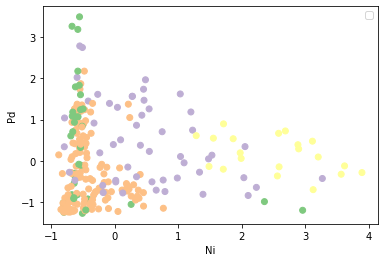

In [31]:
## Plotting clusters
from palettable.colorbrewer.qualitative import Accent_6
colDict = {0: Accent_6.hex_colors[0], 1: Accent_6.hex_colors[1], 2: Accent_6.hex_colors[2], 3: Accent_6.hex_colors[3]}
myCol = [colDict[i] for i in mdl7.labels_]

print(dfSubFinal.columns)

# Plot results
import matplotlib.pyplot as plt
plt.scatter(dfSubFinalarray[:, 5], dfSubFinalarray[:, 11], c=myCol)
plt.xlabel('Ni')
plt.ylabel('Pd')
plt.legend()

In [32]:
# append new cluster groups
dfSubFinal['k=4_All'] = mdl7.labels_
dfSubFinal.head()

,Location,Fe (Z),Mg (Z),Ti (Z),Cr (Z),Ni(Z),Cu(Z),Ir (Z),Ru (Z),Rh (Z),Pt (Z),Pd (Z),k=3_All,k=3_PGE+Trace,k=3_PGE,k=2_All,k=2_PGE+Trace,k=2_PGE,k=4_All
0,Iceland,1.464795,-1.025389,3.596851,-0.956206,-0.775195,-1.183247,-0.746816,-0.683316,-1.056380,-1.324968,-1.187426,0,2,0,0,0,1,0
1,Iceland,-1.347142,0.089927,-0.728239,0.053455,-0.201514,-0.061289,-0.474778,0.554977,0.337289,-0.385261,-0.082642,1,2,2,0,0,1,2
2,Iceland,-1.171396,0.730406,-1.312067,1.462333,1.226990,-0.601491,-0.251388,0.142213,0.214318,-0.160601,0.745468,1,2,2,1,0,1,1
3,Iceland,-1.716209,0.487466,-1.288237,1.819305,0.429155,-0.504532,-0.127283,0.570853,1.034124,0.192091,1.108005,1,0,2,1,1,1,1
4,Iceland,0.468901,-0.806743,1.118562,-0.768215,-0.699210,-0.476829,-0.815653,-0.786508,-1.056380,-1.293563,-1.240853,0,2,0,0,0,1,2


# k=4, PGE+Trace

In [33]:
## K-means
# Fit k-means model
from sklearn.cluster import KMeans
k = 4
mdl8 = KMeans(n_clusters=k, n_jobs=-1, init = 'random', n_init= 1200, max_iter=1500) # -1 uses all cores
mdl8.fit(X=dfSubFinalarray[:,4:11]) # using only the selected variables e.g. major, trace and PGE

KMeans(algorithm='auto', copy_x=True, init='random', max_iter=1500,
       n_clusters=4, n_init=1200, n_jobs=-1, precompute_distances='auto',
       random_state=None, tol=0.0001, verbose=0)

No handles with labels found to put in legend.


Index(['Location', 'Fe (Z)', 'Mg (Z)', 'Ti (Z)', 'Cr (Z)', 'Ni(Z)', 'Cu(Z)',
       'Ir (Z)', 'Ru (Z)', 'Rh (Z)', 'Pt (Z)', 'Pd (Z)', 'k=3_All',
       'k=3_PGE+Trace', 'k=3_PGE', 'k=2_All', 'k=2_PGE+Trace', 'k=2_PGE',
       'k=4_All'],
      dtype='object')


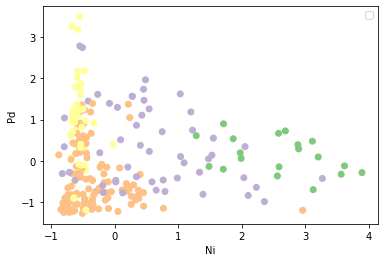

In [34]:
## Plotting clusters
from palettable.colorbrewer.qualitative import Accent_6
colDict = {0: Accent_6.hex_colors[0], 1: Accent_6.hex_colors[1], 2: Accent_6.hex_colors[2], 3: Accent_6.hex_colors[3]}
myCol = [colDict[i] for i in mdl8.labels_]

print(dfSubFinal.columns)

# Plot results
import matplotlib.pyplot as plt
plt.scatter(dfSubFinalarray[:, 5], dfSubFinalarray[:, 11], c=myCol)
plt.xlabel('Ni')
plt.ylabel('Pd')
plt.legend()

In [35]:
# append new cluster groups
dfSubFinal['k=4_PGE+Trace'] = mdl8.labels_
dfSubFinal.head()

,Location,Fe (Z),Mg (Z),Ti (Z),Cr (Z),Ni(Z),Cu(Z),Ir (Z),Ru (Z),Rh (Z),Pt (Z),Pd (Z),k=3_All,k=3_PGE+Trace,k=3_PGE,k=2_All,k=2_PGE+Trace,k=2_PGE,k=4_All,k=4_PGE+Trace
0,Iceland,1.464795,-1.025389,3.596851,-0.956206,-0.775195,-1.183247,-0.746816,-0.683316,-1.056380,-1.324968,-1.187426,0,2,0,0,0,1,0,2
1,Iceland,-1.347142,0.089927,-0.728239,0.053455,-0.201514,-0.061289,-0.474778,0.554977,0.337289,-0.385261,-0.082642,1,2,2,0,0,1,2,2
2,Iceland,-1.171396,0.730406,-1.312067,1.462333,1.226990,-0.601491,-0.251388,0.142213,0.214318,-0.160601,0.745468,1,2,2,1,0,1,1,1
3,Iceland,-1.716209,0.487466,-1.288237,1.819305,0.429155,-0.504532,-0.127283,0.570853,1.034124,0.192091,1.108005,1,0,2,1,1,1,1,1
4,Iceland,0.468901,-0.806743,1.118562,-0.768215,-0.699210,-0.476829,-0.815653,-0.786508,-1.056380,-1.293563,-1.240853,0,2,0,0,0,1,2,2


# k=4, PGE Only

In [36]:
## K-means
# Fit k-means model
from sklearn.cluster import KMeans
k = 4
mdl9 = KMeans(n_clusters=k, n_jobs=-1, init = 'random', n_init= 1200, max_iter=1500) # -1 uses all cores
mdl9.fit(X=dfSubFinalarray[:,7:11]) # using only the selected variables e.g. major, trace and PGE

KMeans(algorithm='auto', copy_x=True, init='random', max_iter=1500,
       n_clusters=4, n_init=1200, n_jobs=-1, precompute_distances='auto',
       random_state=None, tol=0.0001, verbose=0)

No handles with labels found to put in legend.


Index(['Location', 'Fe (Z)', 'Mg (Z)', 'Ti (Z)', 'Cr (Z)', 'Ni(Z)', 'Cu(Z)',
       'Ir (Z)', 'Ru (Z)', 'Rh (Z)', 'Pt (Z)', 'Pd (Z)', 'k=3_All',
       'k=3_PGE+Trace', 'k=3_PGE', 'k=2_All', 'k=2_PGE+Trace', 'k=2_PGE',
       'k=4_All', 'k=4_PGE+Trace'],
      dtype='object')


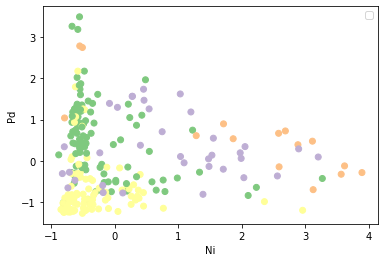

In [37]:
## Plotting clusters
from palettable.colorbrewer.qualitative import Accent_6
colDict = {0: Accent_6.hex_colors[0], 1: Accent_6.hex_colors[1], 2: Accent_6.hex_colors[2], 3: Accent_6.hex_colors[3]}
myCol = [colDict[i] for i in mdl9.labels_]

print(dfSubFinal.columns)

# Plot results
import matplotlib.pyplot as plt
plt.scatter(dfSubFinalarray[:, 5], dfSubFinalarray[:, 11], c=myCol)
plt.xlabel('Ni')
plt.ylabel('Pd')
plt.legend()

In [38]:
# append new cluster groups
dfSubFinal['k=4_PGE'] = mdl9.labels_
dfSubFinal.head()

,Location,Fe (Z),Mg (Z),Ti (Z),Cr (Z),Ni(Z),Cu(Z),Ir (Z),Ru (Z),Rh (Z),...,Pd (Z),k=3_All,k=3_PGE+Trace,k=3_PGE,k=2_All,k=2_PGE+Trace,k=2_PGE,k=4_All,k=4_PGE+Trace,k=4_PGE
0,Iceland,1.464795,-1.025389,3.596851,-0.956206,-0.775195,-1.183247,-0.746816,-0.683316,-1.056380,...,-1.187426,0,2,0,0,0,1,0,2,3
1,Iceland,-1.347142,0.089927,-0.728239,0.053455,-0.201514,-0.061289,-0.474778,0.554977,0.337289,...,-0.082642,1,2,2,0,0,1,2,2,0
2,Iceland,-1.171396,0.730406,-1.312067,1.462333,1.226990,-0.601491,-0.251388,0.142213,0.214318,...,0.745468,1,2,2,1,0,1,1,1,0
3,Iceland,-1.716209,0.487466,-1.288237,1.819305,0.429155,-0.504532,-0.127283,0.570853,1.034124,...,1.108005,1,0,2,1,1,1,1,1,0
4,Iceland,0.468901,-0.806743,1.118562,-0.768215,-0.699210,-0.476829,-0.815653,-0.786508,-1.056380,...,-1.240853,0,2,0,0,0,1,2,2,3


# k=5, All variables

In [51]:
## K-means
# Fit k-means model
from sklearn.cluster import KMeans
k = 5
mdl10 = KMeans(n_clusters=k, n_jobs=-1, init = 'random', n_init= 1200, max_iter=1500) # -1 uses all cores
mdl10.fit(X=dfSubFinalarray[:,1:11]) # using only the selected variables e.g. major, trace and PGE

KMeans(algorithm='auto', copy_x=True, init='random', max_iter=1500,
       n_clusters=5, n_init=1200, n_jobs=-1, precompute_distances='auto',
       random_state=None, tol=0.0001, verbose=0)

No handles with labels found to put in legend.


Index(['Location', 'Fe (Z)', 'Mg (Z)', 'Ti (Z)', 'Cr (Z)', 'Ni(Z)', 'Cu(Z)',
       'Ir (Z)', 'Ru (Z)', 'Rh (Z)', 'Pt (Z)', 'Pd (Z)', 'k=3_All',
       'k=3_PGE+Trace', 'k=3_PGE', 'k=2_All', 'k=2_PGE+Trace', 'k=2_PGE',
       'k=4_All', 'k=4_PGE+Trace', 'k=4_PGE'],
      dtype='object')


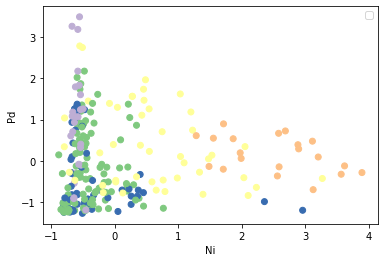

In [54]:
## Plotting clusters
from palettable.colorbrewer.qualitative import Accent_6
colDict = {0: Accent_6.hex_colors[0], 1: Accent_6.hex_colors[1], 2: Accent_6.hex_colors[2], 3: Accent_6.hex_colors[3], 4: Accent_6.hex_colors[4]}
myCol = [colDict[i] for i in mdl10.labels_]

print(dfSubFinal.columns)

# Plot results
import matplotlib.pyplot as plt
plt.scatter(dfSubFinalarray[:, 5], dfSubFinalarray[:, 11], c=myCol)
plt.xlabel('Ni')
plt.ylabel('Pd')
plt.legend()

In [56]:
# append new cluster groups
dfSubFinal['k=5_All'] = mdl10.labels_
dfSubFinal.head()

,Location,Fe (Z),Mg (Z),Ti (Z),Cr (Z),Ni(Z),Cu(Z),Ir (Z),Ru (Z),Rh (Z),...,k=3_All,k=3_PGE+Trace,k=3_PGE,k=2_All,k=2_PGE+Trace,k=2_PGE,k=4_All,k=4_PGE+Trace,k=4_PGE,k=5_All
0,Iceland,1.464795,-1.025389,3.596851,-0.956206,-0.775195,-1.183247,-0.746816,-0.683316,-1.056380,...,0,2,0,0,0,1,0,2,3,4
1,Iceland,-1.347142,0.089927,-0.728239,0.053455,-0.201514,-0.061289,-0.474778,0.554977,0.337289,...,1,2,2,0,0,1,2,2,0,0
2,Iceland,-1.171396,0.730406,-1.312067,1.462333,1.226990,-0.601491,-0.251388,0.142213,0.214318,...,1,2,2,1,0,1,1,1,0,3
3,Iceland,-1.716209,0.487466,-1.288237,1.819305,0.429155,-0.504532,-0.127283,0.570853,1.034124,...,1,0,2,1,1,1,1,1,0,3
4,Iceland,0.468901,-0.806743,1.118562,-0.768215,-0.699210,-0.476829,-0.815653,-0.786508,-1.056380,...,0,2,0,0,0,1,2,2,3,4


# k=5, PGE+Trace

In [58]:
## K-means
# Fit k-means model
from sklearn.cluster import KMeans
k = 5
mdl11 = KMeans(n_clusters=k, n_jobs=-1, init = 'random', n_init= 1200, max_iter=1500) # -1 uses all cores
mdl11.fit(X=dfSubFinalarray[:,4:11]) # using only the selected variables e.g. major, trace and PGE

KMeans(algorithm='auto', copy_x=True, init='random', max_iter=1500,
       n_clusters=5, n_init=1200, n_jobs=-1, precompute_distances='auto',
       random_state=None, tol=0.0001, verbose=0)

No handles with labels found to put in legend.


Index(['Location', 'Fe (Z)', 'Mg (Z)', 'Ti (Z)', 'Cr (Z)', 'Ni(Z)', 'Cu(Z)',
       'Ir (Z)', 'Ru (Z)', 'Rh (Z)', 'Pt (Z)', 'Pd (Z)', 'k=3_All',
       'k=3_PGE+Trace', 'k=3_PGE', 'k=2_All', 'k=2_PGE+Trace', 'k=2_PGE',
       'k=4_All', 'k=4_PGE+Trace', 'k=4_PGE', 'k=5_All'],
      dtype='object')


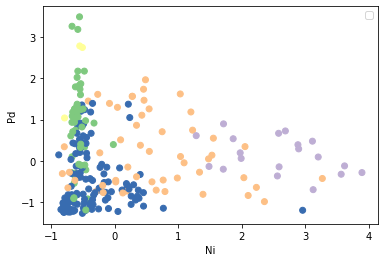

In [59]:
## Plotting clusters
from palettable.colorbrewer.qualitative import Accent_6
colDict = {0: Accent_6.hex_colors[0], 1: Accent_6.hex_colors[1], 2: Accent_6.hex_colors[2], 3: Accent_6.hex_colors[3], 4: Accent_6.hex_colors[4]}
myCol = [colDict[i] for i in mdl11.labels_]

print(dfSubFinal.columns)

# Plot results
import matplotlib.pyplot as plt
plt.scatter(dfSubFinalarray[:, 5], dfSubFinalarray[:, 11], c=myCol)
plt.xlabel('Ni')
plt.ylabel('Pd')
plt.legend()

In [61]:
# append new cluster groups
dfSubFinal['k=5_PGE+Trace'] = mdl11.labels_
dfSubFinal.head()

,Location,Fe (Z),Mg (Z),Ti (Z),Cr (Z),Ni(Z),Cu(Z),Ir (Z),Ru (Z),Rh (Z),...,k=3_PGE+Trace,k=3_PGE,k=2_All,k=2_PGE+Trace,k=2_PGE,k=4_All,k=4_PGE+Trace,k=4_PGE,k=5_All,k=5_PGE+Trace
0,Iceland,1.464795,-1.025389,3.596851,-0.956206,-0.775195,-1.183247,-0.746816,-0.683316,-1.056380,...,2,0,0,0,1,0,2,3,4,4
1,Iceland,-1.347142,0.089927,-0.728239,0.053455,-0.201514,-0.061289,-0.474778,0.554977,0.337289,...,2,2,0,0,1,2,2,0,0,4
2,Iceland,-1.171396,0.730406,-1.312067,1.462333,1.226990,-0.601491,-0.251388,0.142213,0.214318,...,2,2,1,0,1,1,1,0,3,2
3,Iceland,-1.716209,0.487466,-1.288237,1.819305,0.429155,-0.504532,-0.127283,0.570853,1.034124,...,0,2,1,1,1,1,1,0,3,2
4,Iceland,0.468901,-0.806743,1.118562,-0.768215,-0.699210,-0.476829,-0.815653,-0.786508,-1.056380,...,2,0,0,0,1,2,2,3,4,4


# k=5, PGE Only

In [62]:
## K-means
# Fit k-means model
from sklearn.cluster import KMeans
k = 5
mdl12 = KMeans(n_clusters=k, n_jobs=-1, init = 'random', n_init= 1200, max_iter=1500) # -1 uses all cores
mdl12.fit(X=dfSubFinalarray[:,7:11]) # using only the selected variables e.g. major, trace and PGE

KMeans(algorithm='auto', copy_x=True, init='random', max_iter=1500,
       n_clusters=5, n_init=1200, n_jobs=-1, precompute_distances='auto',
       random_state=None, tol=0.0001, verbose=0)

No handles with labels found to put in legend.


Index(['Location', 'Fe (Z)', 'Mg (Z)', 'Ti (Z)', 'Cr (Z)', 'Ni(Z)', 'Cu(Z)',
       'Ir (Z)', 'Ru (Z)', 'Rh (Z)', 'Pt (Z)', 'Pd (Z)', 'k=3_All',
       'k=3_PGE+Trace', 'k=3_PGE', 'k=2_All', 'k=2_PGE+Trace', 'k=2_PGE',
       'k=4_All', 'k=4_PGE+Trace', 'k=4_PGE', 'k=5_All', 'k=5_PGE+Trace'],
      dtype='object')


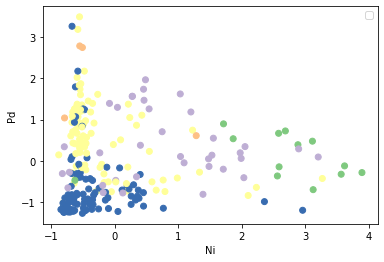

In [63]:
## Plotting clusters
from palettable.colorbrewer.qualitative import Accent_6
colDict = {0: Accent_6.hex_colors[0], 1: Accent_6.hex_colors[1], 2: Accent_6.hex_colors[2], 3: Accent_6.hex_colors[3], 4: Accent_6.hex_colors[4]}
myCol = [colDict[i] for i in mdl12.labels_]

print(dfSubFinal.columns)

# Plot results
import matplotlib.pyplot as plt
plt.scatter(dfSubFinalarray[:, 5], dfSubFinalarray[:, 11], c=myCol)
plt.xlabel('Ni')
plt.ylabel('Pd')
plt.legend()

In [65]:
# append new cluster groups
dfSubFinal['k=5_PGE'] = mdl12.labels_
dfSubFinal.head()

,Location,Fe (Z),Mg (Z),Ti (Z),Cr (Z),Ni(Z),Cu(Z),Ir (Z),Ru (Z),Rh (Z),...,k=3_PGE,k=2_All,k=2_PGE+Trace,k=2_PGE,k=4_All,k=4_PGE+Trace,k=4_PGE,k=5_All,k=5_PGE+Trace,k=5_PGE
0,Iceland,1.464795,-1.025389,3.596851,-0.956206,-0.775195,-1.183247,-0.746816,-0.683316,-1.056380,...,0,0,0,1,0,2,3,4,4,4
1,Iceland,-1.347142,0.089927,-0.728239,0.053455,-0.201514,-0.061289,-0.474778,0.554977,0.337289,...,2,0,0,1,2,2,0,0,4,3
2,Iceland,-1.171396,0.730406,-1.312067,1.462333,1.226990,-0.601491,-0.251388,0.142213,0.214318,...,2,1,0,1,1,1,0,3,2,3
3,Iceland,-1.716209,0.487466,-1.288237,1.819305,0.429155,-0.504532,-0.127283,0.570853,1.034124,...,2,1,1,1,1,1,0,3,2,3
4,Iceland,0.468901,-0.806743,1.118562,-0.768215,-0.699210,-0.476829,-0.815653,-0.786508,-1.056380,...,0,0,0,1,2,2,3,4,4,4


In [66]:
dfSubFinal.to_csv(r'NAIP_Clustered_WITH_k5_Z_Score.csv') #making csv to use in MatLab

# Davies Bouldin Indices

In [39]:
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score
labels = mdl1.labels_
davies_bouldin_score(dfSubFinalarray[:,1:15], labels)

1.5340491553313056

In [40]:
labels = mdl2.labels_
davies_bouldin_score(dfSubFinalarray[:,1:15], labels)

1.4905987810864723

In [41]:
labels = mdl3.labels_
davies_bouldin_score(dfSubFinalarray[:,1:15], labels)

1.8308577464114626

In [42]:
labels = mdl4.labels_
davies_bouldin_score(dfSubFinalarray[:,1:15], labels)

1.143268704941377

In [43]:
labels = mdl5.labels_
davies_bouldin_score(dfSubFinalarray[:,1:15], labels)

1.2089582049094294

In [44]:
labels = mdl6.labels_
davies_bouldin_score(dfSubFinalarray[:,1:15], labels)

1.2328751622487744

In [45]:
labels = mdl7.labels_
davies_bouldin_score(dfSubFinalarray[:,1:15], labels)

1.4183990743979704

In [46]:
labels = mdl8.labels_
davies_bouldin_score(dfSubFinalarray[:,1:15], labels)

1.4051151757417837

In [47]:
labels = mdl9.labels_
davies_bouldin_score(dfSubFinalarray[:,1:15], labels)

1.945748741475278

In [55]:
labels = mdl10.labels_
davies_bouldin_score(dfSubFinalarray[:,1:15], labels)

1.5155688583509186

In [60]:
labels = mdl11.labels_
davies_bouldin_score(dfSubFinalarray[:,1:15], labels)

1.3220911919713099

In [64]:
labels = mdl12.labels_
davies_bouldin_score(dfSubFinalarray[:,1:15], labels)

1.6863437148995686